In [1]:
import os, json, shutil
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
from glob import glob
import pandas as pd
from scipy.ndimage import label as cc_label


SPLITS_DIR = Path(r"D:\master_experiments\data\splits\BraTS2024_Splits")
META_PATH = SPLITS_DIR / "splits_metadata.json"

NNUNET_BASE = Path(r"D:\master_experiments\models_configs\nnUNet_2024")
NNUNET_RAW = NNUNET_BASE / "nnUNet_raw"
NNUNET_PREP = NNUNET_BASE / "nnUNet_preprocessed"
NNUNET_RES = NNUNET_BASE / "nnUNet_results"

for p in [NNUNET_RAW, NNUNET_PREP, NNUNET_RES]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREP)
os.environ["nnUNet_results"] = str(NNUNET_RES)

DATASET_ID = 903
DATASET_NAME = "BraTS2024_Baseline_4ch"
DATASET_FOLDER = NNUNET_RAW / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

for p in [imagesTr, labelsTr, imagesTs]:
    p.mkdir(parents=True, exist_ok=True)

SPLITS_DIR.exists(), META_PATH.exists(), DATASET_FOLDER

(True,
 True,
 WindowsPath('D:/master_experiments/models_configs/nnUNet_2024/nnUNet_raw/Dataset903_BraTS2024_Baseline_4ch'))

In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

train_ids = meta["ids"]["train"]
val_ids = meta["ids"]["val"]
test_ids = meta["ids"]["test"]

train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("Counts:", len(train_ids), len(val_ids), len(test_ids))
print("OK: sem repetição entre splits")

Counts: 945 202 203
OK: sem repetição entre splits


In [3]:
MODS = ["t2f", "t1n", "t1c", "t2w"]
FILE_ENDING = ".nii.gz"

def case_dir(split_name: str, case_id: str) -> Path:
    return SPLITS_DIR / split_name / case_id

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1n":
        cands = [c for c in cands if "t1c" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def save_as_niigz(src_path: Path, dst_path: Path):
    if src_path.name.lower().endswith(".nii.gz"):
        shutil.copy2(src_path, dst_path)
        return
    img = nib.load(str(src_path))
    nib.save(img, str(dst_path))

def save_label_remap_niigz(seg_path: Path, dst_path: Path):
    shutil.copy2(seg_path, dst_path)

def check_case(split_name: str, case_id: str):
    d = case_dir(split_name, case_id)
    assert d.exists(), f"Missing folder: {d}"
    _ = [find_file(d, m) for m in MODS]
    _ = find_file(d, "seg")
    return True

for cid in train_ids[:3]:
    check_case("train", cid)
print("OK")

OK


In [4]:
def export_case_to_nnunet(split_name: str, case_id: str, to_images: Path, to_labels: Path | None):
    d = case_dir(split_name, case_id)
    for ch, mod in enumerate(MODS):
        src = find_file(d, mod)
        dst = to_images / f"{case_id}_{ch:04d}{FILE_ENDING}"
        save_as_niigz(src, dst)
    if to_labels is not None:
        seg = find_file(d, "seg")
        dst = to_labels / f"{case_id}{FILE_ENDING}"
        save_label_remap_niigz(seg, dst)

for cid in tqdm(train_ids, desc="Export train -> imagesTr/labelsTr"):
    export_case_to_nnunet("train", cid, imagesTr, labelsTr)

for cid in tqdm(val_ids, desc="Export val -> imagesTr/labelsTr"):
    export_case_to_nnunet("val", cid, imagesTr, labelsTr)

for cid in tqdm(test_ids, desc="Export test -> imagesTs"):
    export_case_to_nnunet("test", cid, imagesTs, None)

len(list(imagesTr.glob(f"*{FILE_ENDING}"))), len(list(labelsTr.glob(f"*{FILE_ENDING}"))), len(list(imagesTs.glob(f"*{FILE_ENDING}")))

Export test -> imagesTs: 100%|██████████| 203/203 [00:53<00:00,  3.81it/s]


(4588, 1147, 812)

In [5]:
dataset_json = {
    "channel_names": {"0": "FLAIR", "1": "T1n", "2": "t1c", "3": "T2w"},
    "labels": {"background": 0, "NETC": 1, "SNFH": 2, "ET": 3, "RC": 4},
    "numTraining": len(list(labelsTr.glob(f"*{FILE_ENDING}"))),
    "file_ending": FILE_ENDING
}

with open(DATASET_FOLDER / "dataset.json", "w", encoding="utf-8") as f:
    json.dump(dataset_json, f, indent=2, ensure_ascii=False)

DATASET_FOLDER / "dataset.json"

WindowsPath('D:/master_experiments/models_configs/nnUNet_2024/nnUNet_raw/Dataset903_BraTS2024_Baseline_4ch/dataset.json')

In [6]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity -c 3d_fullres -np 4

Fingerprint extraction...
Dataset903_BraTS2024_Baseline_4ch
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [142. 175. 136.], 3d_lowres: [142, 175, 136]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 105, 'patch_size': (np.int64(192), np.int64(160)


100%|##########| 1147/1147 [02:26<00:00,  7.84it/s]

100%|##########| 1147/1147 [24:53<00:00,  1.30s/it]


In [7]:
preprocessed_dataset = NNUNET_PREP / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
preprocessed_dataset.exists()

True

In [8]:
splits_final = [{"train": sorted(train_ids), "val": sorted(val_ids)}]
with open(preprocessed_dataset / "splits_final.json", "w", encoding="utf-8") as f:
    json.dump(splits_final, f, indent=2, ensure_ascii=False)

preprocessed_dataset / "splits_final.json"

WindowsPath('D:/master_experiments/models_configs/nnUNet_2024/nnUNet_preprocessed/Dataset903_BraTS2024_Baseline_4ch/splits_final.json')

In [9]:
prep = Path(os.environ["nnUNet_preprocessed"]) / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
print("Preprocessed dir:", prep)

plans = list(prep.glob("nnUNetPlans*.json"))
print("Plans files:", plans)

if plans:
    with open(plans[0], "r", encoding="utf-8") as f:
        plans_json = json.load(f)
    print("Top keys:", plans_json.keys())

Preprocessed dir: D:\master_experiments\models_configs\nnUNet_2024\nnUNet_preprocessed\Dataset903_BraTS2024_Baseline_4ch
Plans files: [WindowsPath('D:/master_experiments/models_configs/nnUNet_2024/nnUNet_preprocessed/Dataset903_BraTS2024_Baseline_4ch/nnUNetPlans.json')]
Top keys: dict_keys(['dataset_name', 'plans_name', 'original_median_spacing_after_transp', 'original_median_shape_after_transp', 'image_reader_writer', 'transpose_forward', 'transpose_backward', 'configurations', 'experiment_planner_used', 'label_manager', 'foreground_intensity_properties_per_channel'])


In [10]:
!nnUNetv2_train {DATASET_ID} 3d_fullres 0 -device cuda -tr nnUNetTrainer_250epochs


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-04-30 00:44:45.495073: do_dummy_2d_data_aug: False
2026-04-30 00:44:45.510772: Using splits from existing split file: D:\master_experiments\models_configs\nnUNet_2024\nnUNet_preprocessed\Dataset903_BraTS2024_Baseline_4ch\splits_final.json
2026-04-30 00:44:45.510772: The split file contains 

In [11]:
pattern = str(NNUNET_RES / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}" / "*" / "fold_0" / "validation" / "summary.json")
cands = glob(pattern)
cands[:2], len(cands)

(['D:\\master_experiments\\models_configs\\nnUNet_2024\\nnUNet_results\\Dataset903_BraTS2024_Baseline_4ch\\nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres\\fold_0\\validation\\summary.json'],
 1)

In [12]:
if cands:
    with open(cands[0], "r", encoding="utf-8") as f:
        summary = json.load(f)
    list(summary.keys())

In [13]:
PRED_TEST_OUT = Path(r"D:\nnUNet_preds\brats2024_test_pred")
PRED_TEST_OUT.mkdir(parents=True, exist_ok=True)

!nnUNetv2_predict -i "{imagesTs}" -o "{PRED_TEST_OUT}" -d {DATASET_ID} -c 3d_fullres -f 0 -tr nnUNetTrainer_250epochs


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 203 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 203 cases that I would like to predict

Predicting BraTS-GLI-00005-100:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS-GLI-00005-100

Predicting BraTS-GLI-00008-101:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS-GLI-00008-101

Predicting BraTS-GLI-00020-100:
perform_everything_on_device: True
sending off prediction to b


100%|##########| 8/8 [00:03<00:00,  2.21it/s]

100%|##########| 4/4 [00:01<00:00,  3.34it/s]

100%|##########| 8/8 [00:02<00:00,  3.12it/s]

100%|##########| 8/8 [00:02<00:00,  3.11it/s]

100%|##########| 8/8 [00:02<00:00,  3.11it/s]

100%|##########| 8/8 [00:02<00:00,  3.12it/s]

100%|##########| 8/8 [00:02<00:00,  3.13it/s]

100%|##########| 8/8 [00:02<00:00,  3.09it/s]

100%|##########| 8/8 [00:02<00:00,  3.13it/s]

100%|##########| 8/8 [00:02<00:00,  3.11it/s]

100%|##########| 8/8 [00:02<00:00,  3.11it/s]

100%|##########| 8/8 [00:02<00:00,  3.11it/s]

100%|##########| 8/8 [00:02<00:00,  3.12it/s]

100%|##########| 8/8 [00:02<00:00,  3.13it/s]

100%|##########| 8/8 [00:02<00:00,  3.11it/s]

100%|##########| 8/8 [00:02<00:00,  3.13it/s]

100%|##########| 8/8 [00:02<00:00,  3.12it/s]

100%|##########| 8/8 [00:02<00:00,  3.11it/s]

100%|##########| 8/8 [00:02<00:00,  3.11it/s]

100%|##########| 8/8 [00:02<00:00,  3.12it/s]

100%|##########| 8/8 [00:02<00:00,  3.12it/s]

100%|#######

In [14]:
def load_arr(p: Path):
    return np.asanyarray(nib.load(str(p)).dataobj)

def dice(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def get_pred_path(cid: str):
    p = PRED_TEST_OUT / f"{cid}.nii.gz"
    if p.exists():
        return p
    p = PRED_TEST_OUT / f"{cid}.nii"
    if p.exists():
        return p
    raise FileNotFoundError(f"Pred não encontrada para {cid}")

rows = []
for cid in tqdm(test_ids, desc="Dice por caso"):
    gt_path = find_file(case_dir("test", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    rc = dice(gt == 4, pr == 4)
    
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))  # WT BraTS2024 exclui RC
    tc = dice(((gt==1)|(gt==3)),         ((pr==1)|(pr==3)))
    
    rows.append({
        "id":        cid,
        "dice_NETC": d1,
        "dice_SNFH": d2,
        "dice_ET":   d3,
        "dice_RC":   rc,
        "dice_WT":   wt,
        "dice_TC":   tc,
    })

df = pd.DataFrame(rows)
df.describe()

Dice por caso: 100%|██████████| 203/203 [00:27<00:00,  7.50it/s]


,dice_NETC,dice_SNFH,dice_ET,dice_RC,dice_WT,dice_TC
count,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000
mean,0.795659,0.891164,0.719560,0.708851,0.896775,0.701743
std,0.334627,0.114336,0.340065,0.344463,0.119262,0.349508
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.729314,0.878443,0.640091,0.597461,0.884946,0.573696
50%,1.000000,0.919420,0.873662,0.880171,0.929207,0.863002
75%,1.000000,0.948171,0.951600,0.937099,0.954671,0.954087
max,1.000000,0.985517,1.000000,1.000000,0.987045,1.000000


In [15]:
# Análise condicional 1/3: Frequência de presença por classe no GT

presence_rows = []
for cid in tqdm(test_ids, desc="Presença GT"):
    gt = load_arr(find_file(case_dir("test", cid), "seg")).astype(np.int16)
    presence_rows.append({
        "id":        cid,
        "has_NETC":  bool((gt == 1).any()),
        "has_SNFH":  bool((gt == 2).any()),
        "has_ET":    bool((gt == 3).any()),
        "has_RC":    bool((gt == 4).any()),
        "has_WT":    bool(((gt == 1) | (gt == 2) | (gt == 3)).any()),
        "has_TC":    bool(((gt == 1) | (gt == 3)).any()),
    })
pres_df = pd.DataFrame(presence_rows)
df_full = df.merge(pres_df, on="id")

df_presence = pd.DataFrame([
    {"classe":     col,
     "n_presente": int(df_full[col].sum()),
     "n_total":    len(df_full),
     "pct":        100.0 * df_full[col].sum() / len(df_full)}
    for col in ["has_NETC", "has_SNFH", "has_ET", "has_RC", "has_WT", "has_TC"]
])
df_presence.round(2)

Presença GT: 100%|██████████| 203/203 [00:16<00:00, 12.48it/s]


,classe,n_presente,n_total,pct
0,has_NETC,89,203,43.84
1,has_SNFH,203,203,100.00
2,has_ET,150,203,73.89
3,has_RC,169,203,83.25
4,has_WT,203,203,100.00
5,has_TC,152,203,74.88


In [16]:
# Análise condicional 2/3: Dice CONDICIONAL (apenas casos com classe presente no GT)

pairs = [("dice_NETC","has_NETC"), ("dice_SNFH","has_SNFH"), ("dice_ET","has_ET"),
         ("dice_RC","has_RC"),     ("dice_WT","has_WT"),     ("dice_TC","has_TC")]
df_conditional = pd.DataFrame({
    col: df_full.loc[df_full[has], col].reset_index(drop=True)
    for col, has in pairs
})
df_conditional.describe().round(4)

,dice_NETC,dice_SNFH,dice_ET,dice_RC,dice_WT,dice_TC
count,89.0000,203.0000,150.0000,169.0000,203.0000,152.0000
mean,0.5564,0.8912,0.7938,0.7923,0.8968,0.7727
std,0.3628,0.1143,0.2159,0.2426,0.1193,0.2425
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.2045,0.8784,0.7569,0.7826,0.8849,0.6959
50%,0.7059,0.9194,0.8736,0.8966,0.9292,0.8641
75%,0.8623,0.9482,0.9339,0.9354,0.9547,0.9308
max,0.9920,0.9855,0.9788,0.9898,0.9870,0.9897


In [17]:
# Análise condicional 3/3: Bimodalidade (% de Dice=0 e % de Dice≈1, sobre todos os casos)

pairs = [("dice_NETC","has_NETC"), ("dice_SNFH","has_SNFH"), ("dice_ET","has_ET"),
         ("dice_RC","has_RC"),     ("dice_WT","has_WT"),     ("dice_TC","has_TC")]
df_bimodality = pd.DataFrame([
    {"metric":         col,
     "pct_dice_zero": float((df_full[col] == 0.0).mean()) * 100,
     "pct_dice_one":  float((df_full[col] >= 0.999).mean()) * 100}
    for col, _ in pairs
])
df_bimodality.round(2)

,metric,pct_dice_zero,pct_dice_one
0,dice_NETC,10.34,55.17
1,dice_SNFH,0.49,0.00
2,dice_ET,13.79,13.30
3,dice_RC,12.81,4.93
4,dice_WT,0.49,0.00
5,dice_TC,14.78,12.32


In [18]:
# Lesion-wise Dice (LWD) — métrica primária do BraTS 2023+


LW_MIN_SIZE = 50 

def lesion_wise_dice(gt_mask: np.ndarray, pr_mask: np.ndarray, min_size: int = LW_MIN_SIZE) -> float:
    structure = np.ones((3, 3, 3), dtype=int) 
    if not gt_mask.any() and not pr_mask.any():
        return 1.0
    gt_lab, n_gt = cc_label(gt_mask.astype(bool), structure=structure)
    pr_lab, n_pr = cc_label(pr_mask.astype(bool), structure=structure)

    dice_list = []
    matched_pred = set()

    for g in range(1, n_gt + 1):
        gt_l = (gt_lab == g)
        if gt_l.sum() < min_size:
            continue
        overlap_ids = np.unique(pr_lab[gt_l])
        overlap_ids = overlap_ids[overlap_ids > 0]
        if len(overlap_ids) == 0:
            dice_list.append(0.0)  
        else:
            pr_match = np.isin(pr_lab, overlap_ids)
            inter = np.logical_and(gt_l, pr_match).sum()
            denom = gt_l.sum() + pr_match.sum()
            dice_list.append(2.0 * inter / denom if denom > 0 else 0.0)
            matched_pred.update(int(p) for p in overlap_ids)

    # Componentes pred não casados → FP
    for p in range(1, n_pr + 1):
        if p in matched_pred:
            continue
        pr_l = (pr_lab == p)
        if pr_l.sum() < min_size:
            continue
        dice_list.append(0.0)

    return float(np.mean(dice_list)) if dice_list else 1.0


lw_rows = []
for cid in tqdm(test_ids, desc="Lesion-wise Dice"):
    gt = load_arr(find_file(case_dir("test", cid), "seg")).astype(np.int16)
    # BraTS2024: SEM remap — labels nativos {0,1,2,3,4}
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    gt_wt = (gt == 1) | (gt == 2) | (gt == 3)  
    pr_wt = (pr == 1) | (pr == 2) | (pr == 3)
    gt_tc = (gt == 1) | (gt == 3)
    pr_tc = (pr == 1) | (pr == 3)
    gt_et = (gt == 3)
    pr_et = (pr == 3)
    gt_rc = (gt == 4)
    pr_rc = (pr == 4)

    lw_rows.append({
        "id":     cid,
        "lwd_WT": lesion_wise_dice(gt_wt, pr_wt),
        "lwd_TC": lesion_wise_dice(gt_tc, pr_tc),
        "lwd_ET": lesion_wise_dice(gt_et, pr_et),
        "lwd_RC": lesion_wise_dice(gt_rc, pr_rc),
    })

lw_df = pd.DataFrame(lw_rows)
lw_df[["lwd_WT", "lwd_TC", "lwd_ET", "lwd_RC"]].describe().round(4)

Lesion-wise Dice: 100%|██████████| 203/203 [02:50<00:00,  1.19it/s]


,lwd_WT,lwd_TC,lwd_ET,lwd_RC
count,203.0000,203.0000,203.0000,203.0000
mean,0.6855,0.7128,0.7240,0.6973
std,0.2556,0.3251,0.3172,0.3350
min,0.0000,0.0000,0.0000,0.0000
25%,0.4714,0.4942,0.5006,0.4682
50%,0.7567,0.8773,0.8829,0.8781
75%,0.9274,0.9753,0.9730,0.9478
max,0.9870,1.0000,1.0000,1.0000



Paciente: BraTS-GLI-02887-101 | split=test | z=66
Dice NETC (1):   1.0000
Dice SNFH (2):   0.8235
Dice ET   (3):   1.0000
Dice RC   (4):   0.6640
Dice WT (1|2|3): 0.8235
Dice TC (1|3):   1.0000


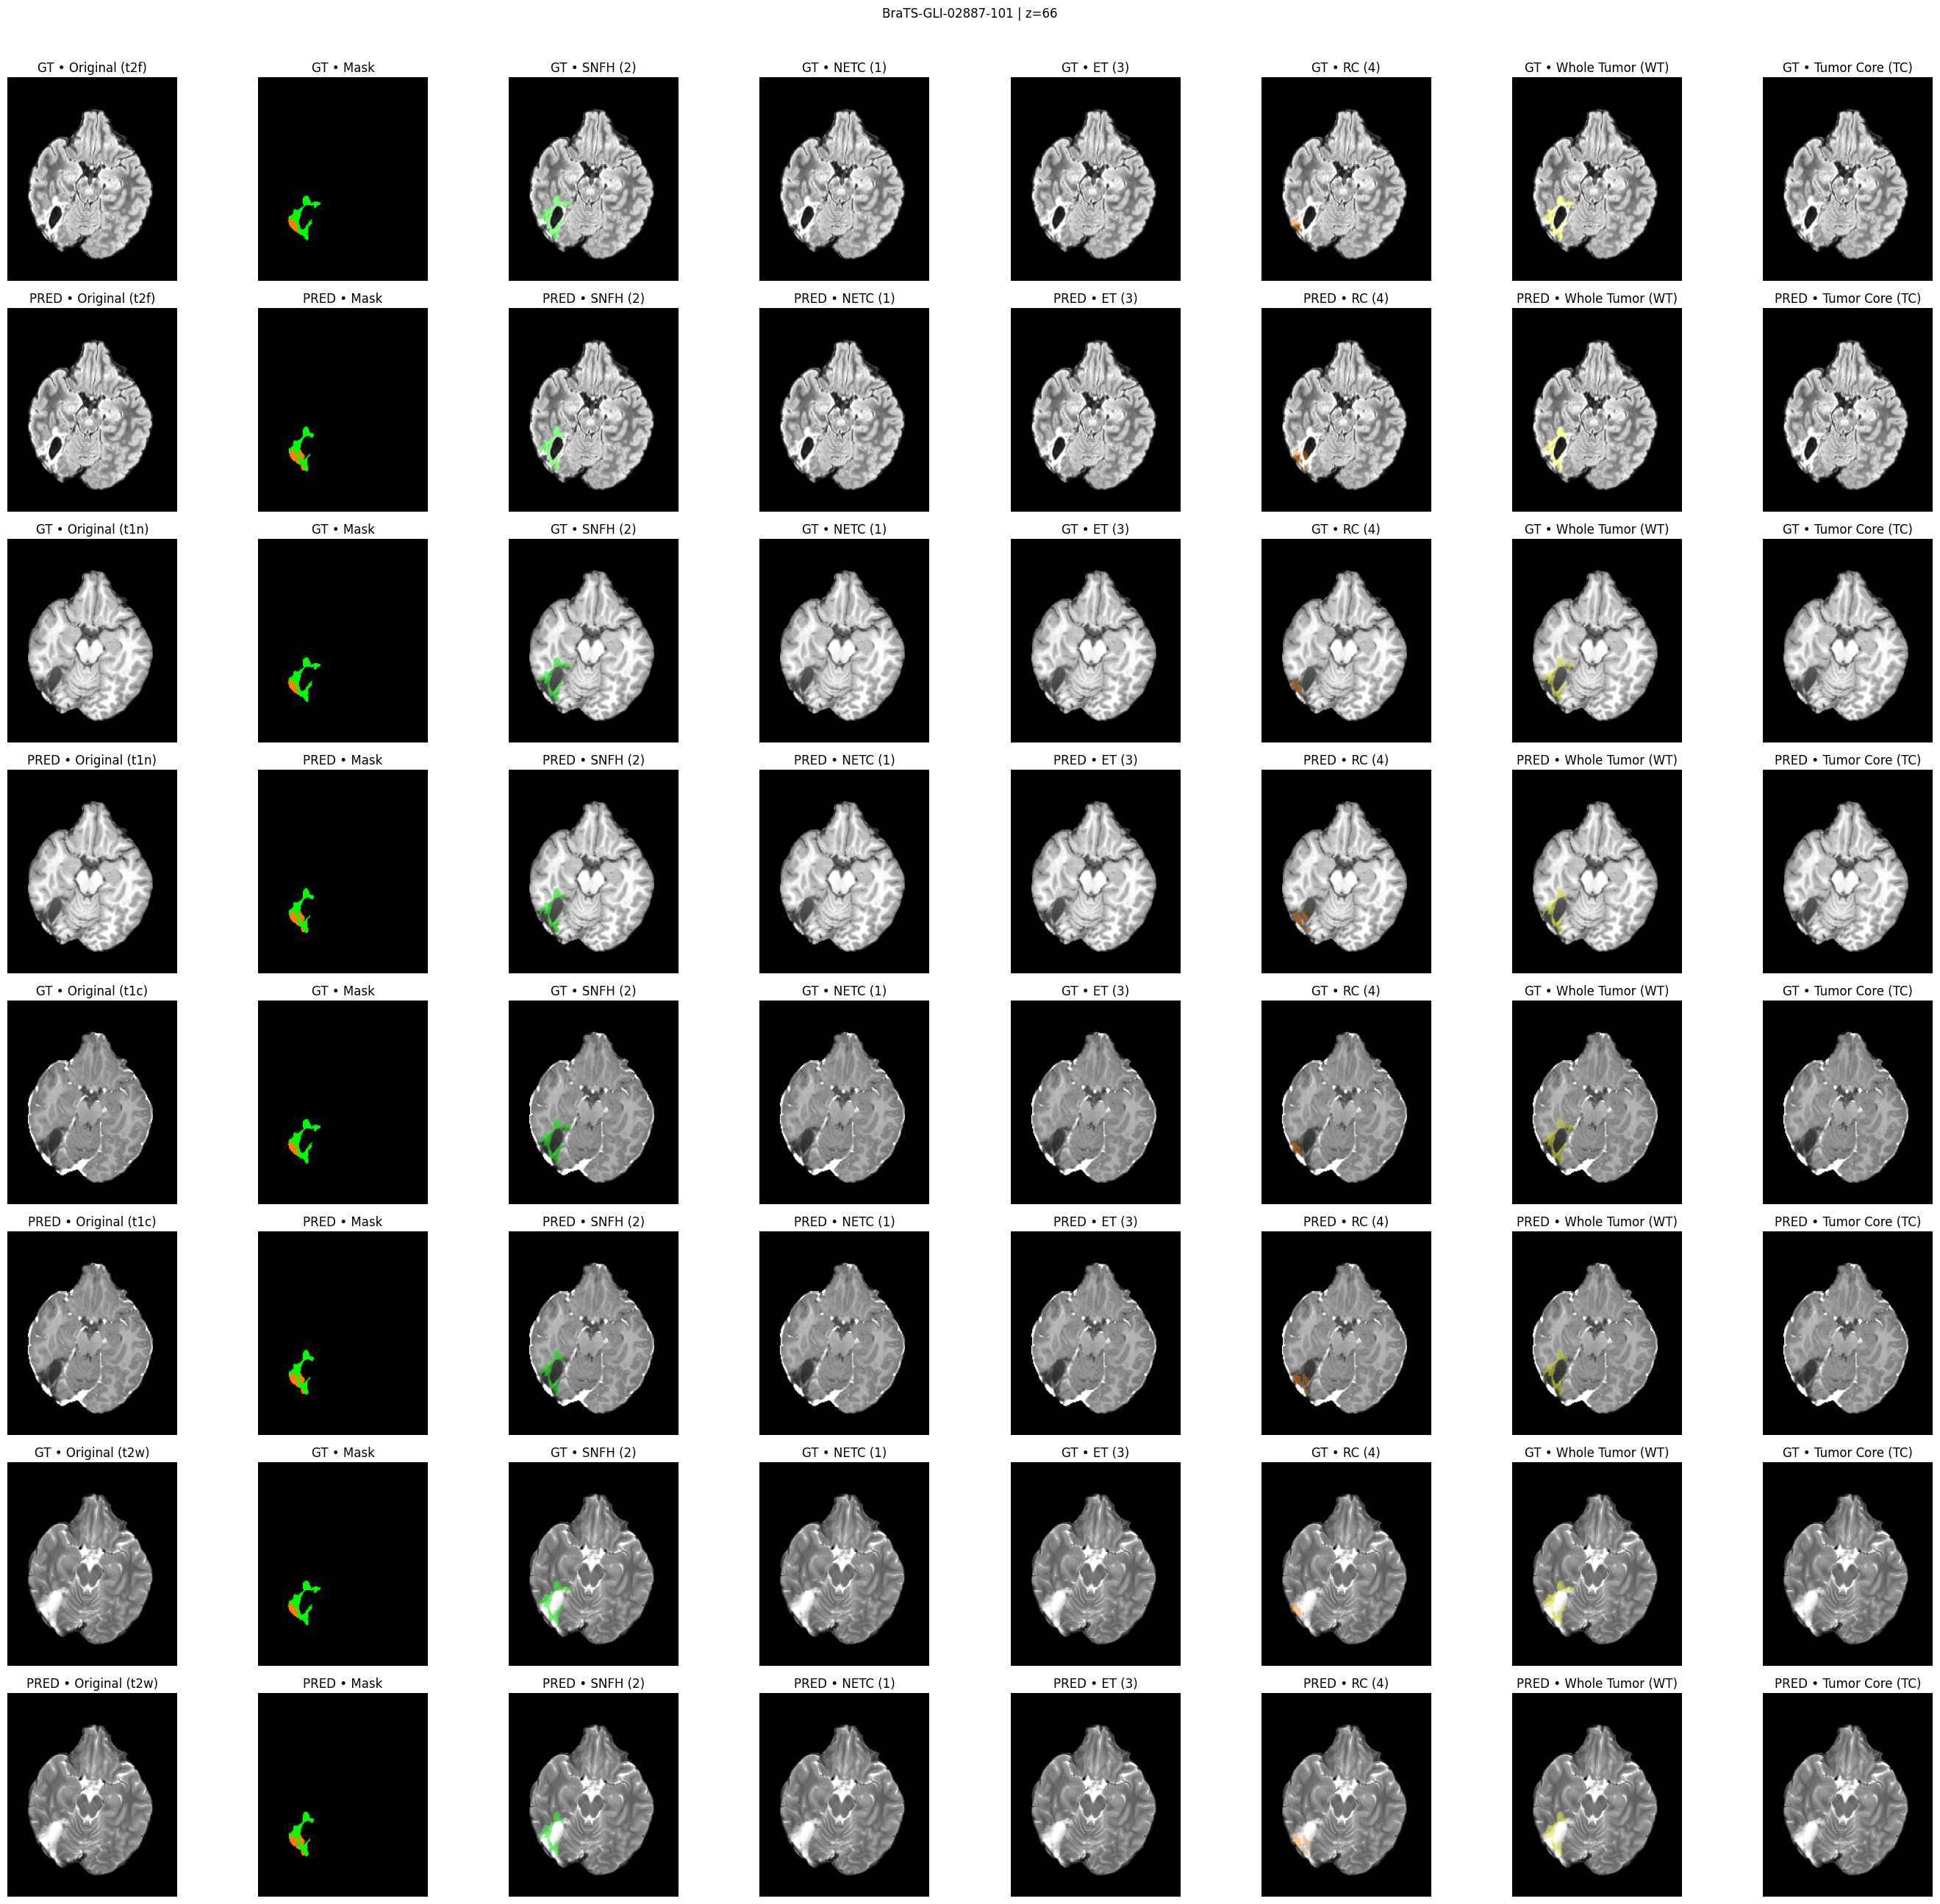

In [19]:
def norm01(x, p1=1, p99=99):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = (x - lo) / (hi - lo)
    return np.clip(x, 0, 1)

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((mask2d.shape[0], mask2d.shape[1], 4), dtype=np.float32)
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = color_rgb
    rgba[..., 3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title)
    ax.axis("off")

def load_arr(p):
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    return np.squeeze(arr)  

def dice(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def pick_best_slice(gt):
    counts = (gt > 0).sum(axis=(0, 1))
    return int(counts.argmax())

cmap_mask = ListedColormap([
    (0, 0, 0, 1),      
    (1, 0, 0, 1),      
    (0, 1, 0, 1),     
    (0, 0, 1, 1),      
    (1, 0.5, 0, 1),   
])
norm_mask = BoundaryNorm([0, 1, 2, 3, 4, 5], cmap_mask.N)

def masks_from_seg(seg):
    nec  = (seg == 1)  
    ede  = (seg == 2)  
    enh  = (seg == 3)  
    rc   = (seg == 4)  
    wt   = (seg==1)|(seg==2)|(seg==3)
    tc   = (seg==1)|(seg==3)
    et   = (seg==3)
    return nec, ede, enh, rc, wt, tc, et

def plot_random_case_multimodal_gt_pred(
    ids_list,
    split_name="test",
    seed=None,
    z=None,
    alpha_cls=0.45,
    alpha_comp=0.35,
):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))

    d = case_dir(split_name, cid)

    gt_path = find_file(d, "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)


    if z is None:
        z = pick_best_slice(gt)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    rc = dice((gt == 4), (pr == 4))
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt==1)|(gt==3)),         ((pr==1)|(pr==3)))
    et = dice((gt==3),                   (pr==3))

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice NETC (1):   {d1:.4f}")
    print(f"Dice SNFH (2):   {d2:.4f}")
    print(f"Dice ET   (3):   {d3:.4f}")
    print(f"Dice RC   (4):   {rc:.4f}")
    print(f"Dice WT (1|2|3): {wt:.4f}")
    print(f"Dice TC (1|3):   {tc:.4f}")

    gt2d = gt[:, :, z].T
    pr2d = pr[:, :, z].T

    gt_nec, gt_ede, gt_enh, gt_rc, gt_wt, gt_tc, _ = masks_from_seg(gt2d)
    pr_nec, pr_ede, pr_enh, pr_rc, pr_wt, pr_tc, _ = masks_from_seg(pr2d)

    n_mods = len(MODS)
    nrows = 2 * n_mods
    ncols = 8

    fig, axes = plt.subplots(nrows, ncols, figsize=(28, 3.2 * nrows))
    fig.suptitle(f"{cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img_path = find_file(d, mod)
        img = load_arr(img_path)
        img2d = norm01(img[:, :, z]).T

        r_gt = 2 * i
        r_pr = 2 * i + 1

        axes[r_gt, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_gt, 0].set_title(f"GT • Original ({mod})")
        axes[r_gt, 0].axis("off")

        axes[r_gt, 1].imshow(gt2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_gt, 1].set_title("GT • Mask")
        axes[r_gt, 1].axis("off")

        overlay(axes[r_gt, 2], img2d, gt_ede, (0, 1, 0), alpha=alpha_cls,  title="GT • SNFH (2)")
        overlay(axes[r_gt, 3], img2d, gt_nec, (1, 0, 0), alpha=alpha_cls,  title="GT • NETC (1)")
        overlay(axes[r_gt, 4], img2d, gt_enh, (0, 0, 1), alpha=alpha_cls,  title="GT • ET (3)")
        overlay(axes[r_gt, 5], img2d, gt_rc,  (1, 0.5, 0), alpha=alpha_cls,  title="GT • RC (4)")
        overlay(axes[r_gt, 6], img2d, gt_wt,  (1, 1, 0), alpha=alpha_comp, title="GT • Whole Tumor (WT)")
        overlay(axes[r_gt, 7], img2d, gt_tc,  (1, 0, 1), alpha=alpha_comp, title="GT • Tumor Core (TC)")

        axes[r_pr, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_pr, 0].set_title(f"PRED • Original ({mod})")
        axes[r_pr, 0].axis("off")

        axes[r_pr, 1].imshow(pr2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_pr, 1].set_title("PRED • Mask")
        axes[r_pr, 1].axis("off")

        overlay(axes[r_pr, 2], img2d, pr_ede, (0, 1, 0), alpha=alpha_cls,  title="PRED • SNFH (2)")
        overlay(axes[r_pr, 3], img2d, pr_nec, (1, 0, 0), alpha=alpha_cls,  title="PRED • NETC (1)")
        overlay(axes[r_pr, 4], img2d, pr_enh, (0, 0, 1), alpha=alpha_cls,  title="PRED • ET (3)")
        overlay(axes[r_pr, 5], img2d, pr_rc,  (1, 0.5, 0), alpha=alpha_cls,  title="PRED • RC (4)")
        overlay(axes[r_pr, 6], img2d, pr_wt,  (1, 1, 0), alpha=alpha_comp, title="PRED • Whole Tumor (WT)")
        overlay(axes[r_pr, 7], img2d, pr_tc,  (1, 0, 1), alpha=alpha_comp, title="PRED • Tumor Core (TC)")

    plt.tight_layout()
    plt.show()

    return cid, z, {"dice_NETC": d1, "dice_SNFH": d2, "dice_ET": d3, "dice_RC": rc, "dice_WT": wt, "dice_TC": tc}

cid, z, dice_dict = plot_random_case_multimodal_gt_pred(test_ids, split_name="test", seed=None)